# Training run 4: figures

**Toward Personalized Hebrew ASR** · Dolev Abudi, Hadas Yonat

The personal-data curve (plan v4, 2026-10-04): four speakers trained beyond 80 minutes, 23558 and 23641
up to 1,440. `docs/training_run4.md` has the write-up and `docs/STATUS.md` is where the project stands.
This notebook draws the paper's two curve figures: Figure 5 (the two 24-hour speakers) and its appendix
companion (the two 6-hour speakers).

| | file | what |
|---|---|---|
| results | `src/training/outputs/results_v4.csv` | every own cell of run 4 with its control, plus run 3's cells of 23558 and 30752 |
| curve | `src/training/outputs/curve_v4.csv` | per speaker and test: personalization at each budget and Δ (top − 80) with its shared-chunk bootstrap |

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Okabe-Ito, colour-blind safe; the roles are run 3's (training_run3_figures.ipynb)
C_OWN, C_CTRL, C_PERS = '#0072B2', '#D55E00', '#009E73'
OUT = os.path.join('..', 'src', 'training', 'outputs')
FIG = os.path.join('..', 'docs', 'figures', 'training_run4'); os.makedirs(FIG, exist_ok=True)
PAPER = os.path.join('..', 'paper', 'Toward_Personalized_Hebrew_ASR_overleaf', 'figures')
def save(fig, name):
    for d in (FIG, PAPER): fig.savefig(os.path.join(d, name + '.png'), dpi=300, bbox_inches='tight')

R = pd.read_csv(os.path.join(OUT, 'results_v4.csv'))
# own cells joined to their control, protocol targets, the rank-8 recipe (the r = 32 check is reported apart)
R = R[~R.control & R.control_cell.notna() & (R.targets == 'protocol') & R.cell.str.contains('_hq') & (R['rank'] == 8)]
C = pd.read_csv(os.path.join(OUT, 'curve_v4.csv')).set_index(['speaker', 'test'])
TESTS = [('test07.', 'test07', 'full test'), ('', 'hq', 'clean test')]
R.groupby(['speaker', 'budget']).seed.nunique().unstack()

budget,5,20,80,160,360,720,1440
speaker,,,,,,,
23558,1.0,1.0,3.0,1.0,3.0,1.0,3.0
23635,1.0,1.0,3.0,1.0,3.0,NaN,NaN
23641,1.0,1.0,3.0,1.0,3.0,1.0,3.0
30752,1.0,1.0,3.0,1.0,3.0,NaN,NaN


Each panel: the own adapter, the control and personalization (own − control), in % of arm B's WER.
Filled markers are means of seeds 0–2 (small dots: the single seeds), hollow ones seed 0. Above each
panel, Δ = personalization at the top budget − at 80 minutes, with its 95 % paired-bootstrap interval.

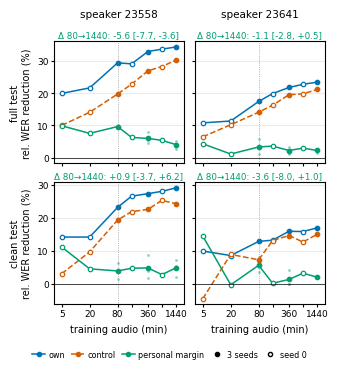

In [2]:
def curve(speakers, xmax):
    B = [b for b in (5, 20, 80, 160, 360, 720, 1440) if b <= xmax]
    plt.rcParams.update({'font.size': 7, 'axes.titlesize': 6.3, 'axes.labelsize': 7, 'xtick.labelsize': 6.5, 'ytick.labelsize': 6.5})
    fig, axes = plt.subplots(2, len(speakers), figsize=(3.4, 3.65), sharex=True, sharey='row')
    for r, (pre, key, tname) in enumerate(TESTS):
        for c, s in enumerate(speakers):
            ax = axes[r, c]; g = R[R.speaker == s]
            m = g.groupby('budget').agg(own=(pre + 'delta_rel', 'mean'), ctrl=(pre + 'control_delta_rel', 'mean'),
                                        pers=(pre + 'personalization_rel', 'mean'), n=('seed', 'nunique'))
            for col, colr, ls in (('own', C_OWN, '-'), ('ctrl', C_CTRL, '--'), ('pers', C_PERS, '-')):
                y = 100 * m[col].values
                ax.plot(m.index, y, ls, color=colr, lw=1.1)
                for xi, yi, n in zip(m.index, y, m.n):
                    ax.plot(xi, yi, 'o', ms=3.2, color=colr, mfc=colr if n == 3 else 'white', mew=.9)
            for b, gb in g.groupby('budget'):
                if len(gb) > 1: ax.scatter([b] * len(gb), 100 * gb[pre + 'personalization_rel'], s=4, color=C_PERS, alpha=.45, lw=0)
            ax.axhline(0, color='k', lw=.5); ax.axvline(80, color='grey', lw=.5, ls=':')
            ax.set_xscale('log'); ax.minorticks_off()
            ax.set_xticks(B, [str(b) if b not in (160, 720) else '' for b in B]); ax.set_xlim(B[0] / 1.5, B[-1] * 1.5)
            ax.grid(axis='y', alpha=.25); ax.tick_params(length=2, pad=1.5)
            d = C.loc[(s, key)]
            ax.set_title(f'Δ 80→{int(d.top_budget)}: {100*d.delta:+.1f} [{100*d.ci_lo:+.1f}, {100*d.ci_hi:+.1f}]', color=C_PERS, pad=2.5)
            if r == 0: ax.annotate(f'speaker {s}', (.5, 1.2), xycoords='axes fraction', ha='center', fontsize=7.5)
            if c == 0: ax.set_ylabel(f'{tname}\nrel. WER reduction (%)')
            if r == 1: ax.set_xlabel('training audio (min)')
    handles = [Line2D([], [], color=C_OWN, marker='o', ms=3, lw=1.1, label='own'),
               Line2D([], [], color=C_CTRL, ls='--', marker='o', ms=3, lw=1.1, label='control'),
               Line2D([], [], color=C_PERS, marker='o', ms=3, lw=1.1, label='personal margin'),
               Line2D([], [], color='k', marker='o', ms=3, ls='', label='3 seeds'),
               Line2D([], [], color='k', marker='o', ms=3, ls='', mfc='white', label='seed 0')]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, bbox_to_anchor=(.5, -.01), fontsize=5.8,
               handlelength=1.6, columnspacing=.8, handletextpad=.4)
    fig.tight_layout(rect=(0, .05, 1, 1), h_pad=.6, w_pad=.4)
    return fig

fig = curve([23558, 23641], 1440); save(fig, 'stage2_data_curve_24h'); plt.show()

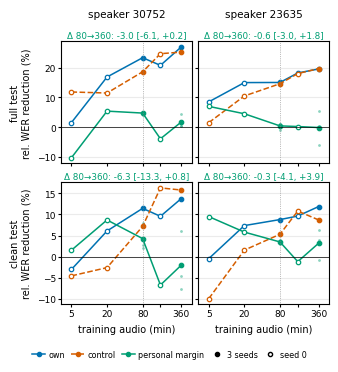

In [3]:
fig = curve([30752, 23635], 360); save(fig, 'stage2_data_curve_6h'); plt.show()

The numbers the paper quotes (full test, % of arm B's WER): own, control and personalization at 80 minutes and at the top budget.

In [4]:
rows = []
for s, g in R.groupby('speaker'):
    top = g.budget.max()
    for b in (80, top):
        d = g[g.budget == b]
        rows.append(dict(speaker=s, budget=b, seeds=len(d), own=100 * d['test07.delta_rel'].mean(),
                         control=100 * d['test07.control_delta_rel'].mean(), personalization=100 * d['test07.personalization_rel'].mean()))
pd.DataFrame(rows).round(1)

,speaker,budget,seeds,own,control,personalization
0,23558,80,3,29.4,19.7,9.7
1,23558,1440,3,34.3,30.2,4.1
2,23635,80,3,15.0,14.6,0.4
3,23635,360,3,19.5,19.7,-0.1
4,23641,80,3,17.4,14.1,3.3
5,23641,1440,3,23.4,21.2,2.3
6,30752,80,3,23.3,18.6,4.7
7,30752,360,3,26.9,25.2,1.7
